# Image Quality Metrics

Computes three sharpness/blur proxies on **each preprocessed test image** across all variants:

| Metric | Direction | Meaning |
|---|---|---|
| `fwhm_mm` | lower = sharper | Whole-brain Gaussian FWHM blur estimate |
| `hi_freq_energy` | higher = sharper | Fraction of spectral power above 0.25 Nyquist |
| `lap_var` | higher = sharper | Variance of Laplacian (edge strength) |

**Variants evaluated:**
- `test_hires` — natural high-quality images (138 subjects)
- `test_lores` — natural low-quality images (198 subjects)
- `Crude` — isotropic downsampling to 3 mm, resampled back to 1 mm
- `ThickSlices` — thick axial slices (3 mm z), resampled back
- `InPlaneCoarse` — in-plane coarsening (3x3x1 mm), resampled back
- `ReducedSNR` — Gaussian noise added in k-space
- `RigidJitter` — random rigid slice jitter

**Output:** `image_quality_metrics_all_variants_<timestamp>.csv` saved in this folder.


In [1]:
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
from numpy.fft import fftn, fftshift
from scipy.ndimage import laplace
from joblib import Parallel, delayed
import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined")
SPLIT_BASE = BASE / "A_A_Combined_Data/Processed_HiresLowres_Split_Data"
DOWN_BASE  = BASE / "A_A_Combined_Data/Downsampled_Data"
OUT_DIR    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")

# ── Dataset configs ────────────────────────────────────────────────────────────
DATASETS = [
    {"variant": "test_hires",    "t1_dir": SPLIT_BASE / "test_hires/t1"},
    {"variant": "test_lores",    "t1_dir": SPLIT_BASE / "test_lores/t1"},
    {"variant": "Crude",         "t1_dir": DOWN_BASE / "Crude/t1"},
    {"variant": "ThickSlices",   "t1_dir": DOWN_BASE / "ThickSlices/t1"},
    {"variant": "InPlaneCoarse", "t1_dir": DOWN_BASE / "InPlaneCoarse/t1"},
    {"variant": "ReducedSNR",    "t1_dir": DOWN_BASE / "ReducedSNR/t1"},
    {"variant": "RigidJitter",   "t1_dir": DOWN_BASE / "RigidJitter/t1"},
]

N_JOBS = 12

# Verify all paths
for ds in DATASETS:
    p = ds["t1_dir"]
    status = "OK" if p.exists() else "MISSING"
    n = len(list(p.glob("*.nii.gz"))) if p.exists() else 0
    print(f"  [{status}] {ds['variant']:20s}  {n:>4d} T1s")


  [OK] test_hires             138 T1s
  [OK] test_lores             198 T1s
  [OK] Crude                  138 T1s
  [OK] ThickSlices            138 T1s
  [OK] InPlaneCoarse          138 T1s
  [OK] ReducedSNR             138 T1s
  [OK] RigidJitter            138 T1s


In [2]:
# ── Quality metric functions (ported from ARC_ATLAS_Combined_Prep.ipynb) ────────

def _key_from_path(p: Path) -> str:
    name = p.name
    for suffix in ["_T1w_MNI_norm.nii.gz", ".nii.gz"]:
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name

def _zscore_brain(vol):
    m = vol != 0
    if not m.any():
        return vol.astype(np.float32), m
    v = vol[m].astype(np.float32)
    mu, sd = v.mean(), (v.std() or 1.0)
    out = np.zeros_like(vol, dtype=np.float32)
    out[m] = (vol[m] - mu) / sd
    return out, m

def estimate_fwhm_gaussian_acf(img, mask):
    cors = {}
    for s in [1, 2, 3]:
        for axis in range(3):
            sl_f = [slice(None)] * 3
            sl_g = [slice(None)] * 3
            sl_f[axis] = slice(0, -s)
            sl_g[axis] = slice(s, None)
            f, g = img[tuple(sl_f)], img[tuple(sl_g)]
            m = mask[tuple(sl_f)] & mask[tuple(sl_g)]
            if m.sum() < 1000:
                continue
            fv = f[m] - f[m].mean()
            gv = g[m] - g[m].mean()
            r = (fv * gv).mean() / ((fv.std() * gv.std()) + 1e-8)
            cors.setdefault(s, []).append(float(r))
    if not cors:
        return np.nan
    s2 = np.array(sorted(cors), dtype=float) ** 2
    R = np.array([np.mean(cors[s]) for s in sorted(cors)])
    lnR = np.log(np.clip(R, 1e-6, 0.999))
    A = np.vstack([np.ones_like(s2), s2]).T
    a, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
    if b >= 0:
        return np.nan
    return float(2.355 * np.sqrt(-1.0 / (2.0 * b)))

def high_freq_energy_ratio(img, mask, cutoff=0.25):
    vol = np.zeros_like(img, dtype=np.float32)
    vol[mask] = img[mask]
    F = fftshift(fftn(vol))
    P = (np.abs(F) ** 2).astype(np.float64)
    nx, ny, nz = img.shape
    cx, cy, cz = (np.array(img.shape) - 1) / 2.0
    X, Y, Z = np.meshgrid(
        np.arange(nx) - cx,
        np.arange(ny) - cy,
        np.arange(nz) - cz,
        indexing="ij",
    )
    r = np.sqrt(((X / (nx / 2)) ** 2 + (Y / (ny / 2)) ** 2 + (Z / (nz / 2)) ** 2) / 3.0)
    return float(P[r >= cutoff].sum() / (P.sum() + 1e-12))

def laplacian_variance(img, mask):
    return float(laplace(img)[mask].var())

def compute_metrics_for_file(t1_path: Path, variant: str) -> dict:
    key = _key_from_path(t1_path)
    try:
        vol = nib.load(str(t1_path)).get_fdata().astype(np.float32)
        zimg, m = _zscore_brain(vol)
        if m.sum() < 5000:
            return dict(variant=variant, key=key, path=str(t1_path),
                        fwhm_mm=float("nan"), hi_freq_energy=float("nan"),
                        lap_var=float("nan"), error="too_few_brain_voxels")
        return dict(
            variant=variant,
            key=key,
            path=str(t1_path),
            fwhm_mm=estimate_fwhm_gaussian_acf(zimg, m),
            hi_freq_energy=high_freq_energy_ratio(zimg, m),
            lap_var=laplacian_variance(zimg, m),
            error=None,
        )
    except Exception as e:
        return dict(variant=variant, key=key, path=str(t1_path),
                    fwhm_mm=float("nan"), hi_freq_energy=float("nan"),
                    lap_var=float("nan"), error=str(e))

print("Quality metric functions ready.")


Quality metric functions ready.


In [3]:
# ── Run computation ───────────────────────────────────────────────────────────
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_CSV = OUT_DIR / f"image_quality_metrics_all_variants_{ts}.csv"

all_rows = []
for ds in DATASETS:
    variant = ds["variant"]
    t1_dir  = ds["t1_dir"]
    if not t1_dir.exists():
        print(f"[SKIP] {variant}: directory not found ({t1_dir})")
        continue
    files = sorted(t1_dir.glob("*.nii.gz"))
    if not files:
        print(f"[SKIP] {variant}: no .nii.gz files found")
        continue
    print(f"[{variant}] Processing {len(files)} T1s with {N_JOBS} workers...")
    rows = Parallel(n_jobs=N_JOBS, backend="loky", verbose=0)(
        delayed(compute_metrics_for_file)(f, variant) for f in files
    )
    all_rows.extend(rows)
    errors = [r for r in rows if r.get("error")]
    print(f"  done. Errors: {len(errors)}")

df = pd.DataFrame(all_rows)
df.to_csv(OUT_CSV, index=False)
print(f"\nSaved {len(df)} rows -> {OUT_CSV}")
df.groupby("variant")[["fwhm_mm", "hi_freq_energy", "lap_var"]].mean().round(4)


[test_hires] Processing 138 T1s with 12 workers...


Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 635, in run
    self.flag_executor_shutting_down()
  File "/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 856, in flag_executor_shutting_down
    self.kill_workers(reason="executor shutting down")
  File "/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 866, in kill_workers
    kill_process_tree(p)
  File "/home/rbielski/miniconda3/envs/tf_310/lib/python3.10/site-packages/joblib/externals/loky/backend/utils.py", line 19, in kill_process_tree
    _kill_process_tree_with_psutil(process)
  File "/home/rbielski/miniconda3/envs/tf_310/lib/

KeyboardInterrupt: 

In [ ]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("Mean quality metrics per variant (fwhm lower=sharper, hfe/lapvar higher=sharper):")
print("=" * 80)
for variant, grp in df.groupby("variant", sort=False):
    n = len(grp)
    fwhm  = grp["fwhm_mm"].median()
    hfe   = grp["hi_freq_energy"].median()
    lv    = grp["lap_var"].median()
    print(f"  {variant:20s}  n={n:>3d}  fwhm={fwhm:.3f}  hfe={hfe:.4f}  lapvar={lv:.4f}")

print("\nWithin-key spread across variants (should be > 0 for degraded vs natural):")
for col in ["fwhm_mm", "hi_freq_energy", "lap_var"]:
    spread = df.groupby("key")[col].agg(lambda s: float(np.nanmax(s) - np.nanmin(s)))
    print(f"  {col:22s}  median_spread={spread.median():.4f}  max_spread={spread.max():.4f}")


Mean quality metrics per variant (fwhm lower=sharper, hfe/lapvar higher=sharper):
  test_hires            n=138  fwhm=11.172  hfe=0.0555  lapvar=0.8118
  test_lores            n=198  fwhm=13.798  hfe=0.0308  lapvar=0.4378
  Crude                 n=138  fwhm=12.217  hfe=0.0865  lapvar=1.1262
  ThickSlices           n=138  fwhm=15.410  hfe=0.0366  lapvar=0.3843
  InPlaneCoarse         n=138  fwhm=15.104  hfe=0.0321  lapvar=0.4261
  ReducedSNR            n=138  fwhm=16.422  hfe=0.0262  lapvar=0.4238
  RigidJitter           n=138  fwhm=12.800  hfe=0.1007  lapvar=1.3391

Within-key spread across variants (should be > 0 for degraded vs natural):
  fwhm_mm                 median_spread=0.0000  max_spread=10.4463
  hi_freq_energy          median_spread=0.0000  max_spread=0.1895
  lap_var                 median_spread=0.0000  max_spread=2.6820


## Next Steps

Once `image_quality_metrics_all_variants_<timestamp>.csv` is generated:

### 1. Merge image-level metrics into evaluation CSVs

The existing `_metrics_with_manifest_*.csv` files contain `mf_fwhm_mm`, `mf_hi_freq_energy`,
`mf_lap_var` computed on the **original undegraded** images — these are constant within each
subject across degraded variants. Replace them with the image-level values computed here:

```python
import pandas as pd
from pathlib import Path

QM = pd.read_csv("image_quality_metrics_all_variants_YYYYMMDD_HHMMSS.csv")
QM = QM.rename(columns={
    "fwhm_mm":       "mf_fwhm_mm",
    "hi_freq_energy":"mf_hi_freq_energy",
    "lap_var":       "mf_lap_var",
}).drop(columns=["path", "error"], errors="ignore")

VARIANT_MAP = {
    "test_crude_metrics_with_manifest_*.csv": "Crude",
    "test_thickslices_metrics_with_manifest_*.csv": "ThickSlices",
    # ... etc
}

RUN_DIR = Path(".../runs/20251110_101813/test_eval")
for glob_pat, qm_variant in VARIANT_MAP.items():
    csv = sorted(RUN_DIR.glob(glob_pat))[-1]
    eval_df = pd.read_csv(csv)
    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        eval_df = eval_df.drop(columns=[c], errors="ignore")
    qm_sub = QM[QM["variant"] == qm_variant][["key", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]
    eval_df = eval_df.merge(qm_sub, on="key", how="left")
    eval_df.to_csv(csv, index=False)
    print(f"Updated {csv.name}")
```

### 2. Re-run `ARC_ATLAS_Test_v3_Mixed_Effect_Model.ipynb`

With image-level quality metrics, the within-key spread will be > 0 and the model
will fit `quality -> Dice` relationships properly.


Loading: image_quality_metrics_all_variants_20260325_161444.csv  |  1026 rows


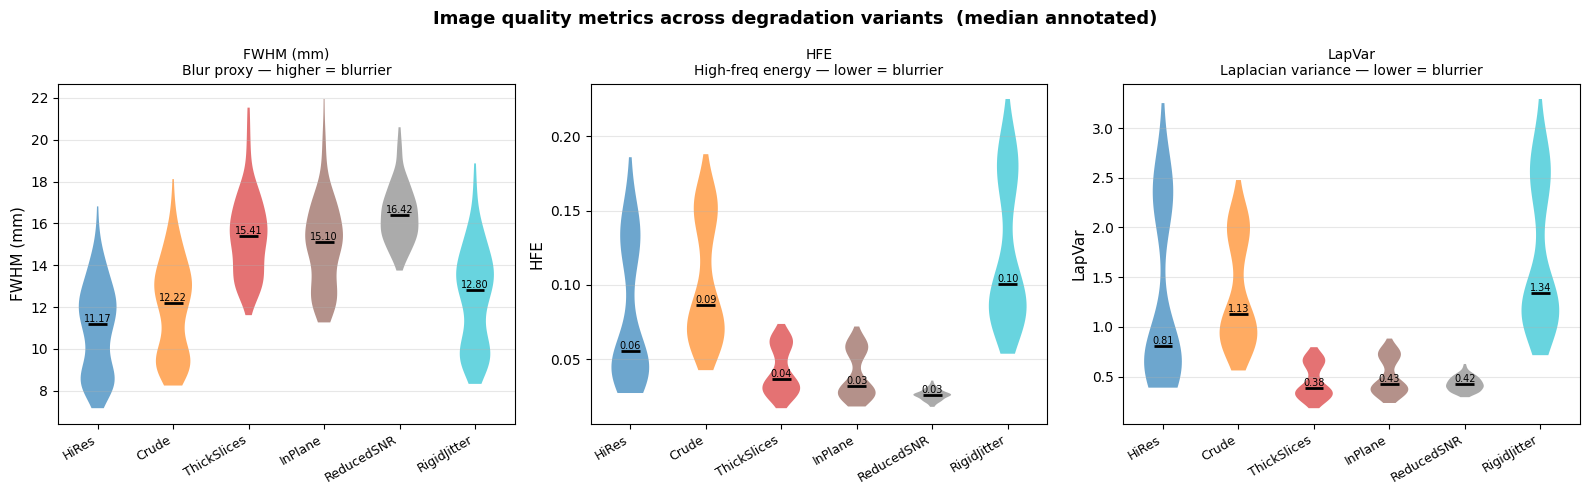

Saved → iqm_violin_plots.png


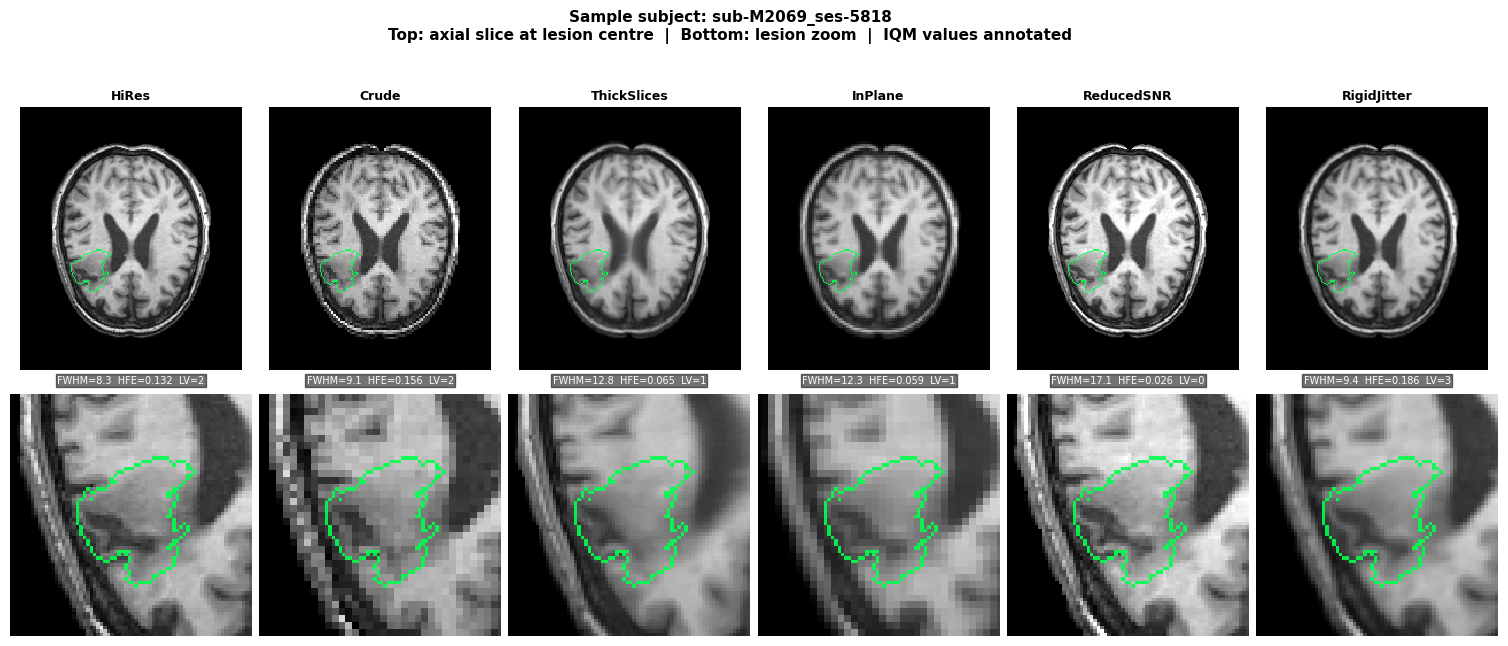

Saved → iqm_sample_image_strip.png


In [2]:
# === Image Quality Metrics — Visualisation ===
# Self-contained — run without executing other cells.
# Produces two figures:
#   1. Violin plots of FWHM, HFE, LapVar across hires-derived variants
#   2. Sample image strip: one subject across those same 6 variants
# Note: test_lores is excluded — it is a separate subject pool (naturally low-quality
#       clinical scans) and cannot be paired with the hires-derived variants.

from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage

IQM_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
BASE_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")

csvs = sorted(IQM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
assert csvs, f"No IQM CSV found in {IQM_DIR}"
df = pd.read_csv(csvs[-1])
print(f"Loading: {csvs[-1].name}  |  {len(df)} rows")

# Hires-derived variants only
VARIANT_ORDER = ["test_hires", "Crude", "ThickSlices", "InPlaneCoarse", "ReducedSNR", "RigidJitter"]
VARIANT_LABELS = {
    "test_hires":    "HiRes",
    "Crude":         "Crude",
    "ThickSlices":   "ThickSlices",
    "InPlaneCoarse": "InPlane",
    "ReducedSNR":    "ReducedSNR",
    "RigidJitter":   "RigidJitter",
}
present = [v for v in VARIANT_ORDER if v in df["variant"].values]
colors  = plt.cm.tab10(np.linspace(0, 0.9, len(present)))

# ── Figure 1: Violin plots ────────────────────────────────────────────────────
metrics = [
    ("fwhm_mm",        "FWHM (mm)",  "Blur proxy — higher = blurrier"),
    ("hi_freq_energy", "HFE",        "High-freq energy — lower = blurrier"),
    ("lap_var",        "LapVar",     "Laplacian variance — lower = blurrier"),
]
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, ylabel, subtitle) in zip(axes1, metrics):
    data   = [df.loc[df["variant"] == v, col].dropna().values for v in present]
    labels = [VARIANT_LABELS.get(v, v) for v in present]
    parts  = ax.violinplot(data, positions=range(len(present)), showmedians=True, showextrema=False)
    for pc, c in zip(parts["bodies"], colors):
        pc.set_facecolor(c); pc.set_alpha(0.65)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"{ylabel}\n{subtitle}", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    for i, d in enumerate(data):
        if len(d):
            ax.text(i, np.median(d), f"{np.median(d):.2f}",
                    ha="center", va="bottom", fontsize=7, color="black")
fig1.suptitle("Image quality metrics across degradation variants  (median annotated)",
              fontsize=13, fontweight="bold")
fig1.tight_layout()
fig1.savefig(IQM_DIR / "iqm_violin_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → iqm_violin_plots.png")

# ── Figure 2: Image strip ─────────────────────────────────────────────────────
VARIANT_DIRS = {
    "test_hires":    BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1",
    "Crude":         BASE_DIR / "Downsampled_Data/test_hires_crude_down/t1",
    "ThickSlices":   BASE_DIR / "Downsampled_Data/test_hires_thick_slices/t1",
    "InPlaneCoarse": BASE_DIR / "Downsampled_Data/test_hires_inplane_2x2x1mm_backTo1mm/t1",
    "ReducedSNR":    BASE_DIR / "Downsampled_Data/test_hires_snr_kspace_v1/t1",
    "RigidJitter":   BASE_DIR / "Downsampled_Data/test_hires_motion_slicejitter/t1",
}
MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"

candidate_key = None
for f in sorted(VARIANT_DIRS["test_hires"].glob("*_T1w_MNI_norm.nii.gz")):
    key = f.name.replace("_T1w_MNI_norm.nii.gz", "")
    mp  = MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    if not mp.exists():
        continue
    nvox = int((nib.load(str(mp)).get_fdata() > 0).sum())
    if nvox < 500 or nvox > 50000:
        continue
    if all((VARIANT_DIRS[v] / f.name).exists() for v in present if v != "test_hires"):
        candidate_key = key
        break

if candidate_key is None:
    print("No shared subject found for image strip")
else:
    fname   = f"{candidate_key}_T1w_MNI_norm.nii.gz"
    mask    = nib.load(str(MASK_DIR / f"{candidate_key}_lesion_mask_MNI_clean.nii.gz")).get_fdata() > 0
    z_best  = int(np.argmax(mask.sum(axis=(0, 1))))
    contour = ndimage.binary_dilation(mask[:, :, z_best].T) ^ mask[:, :, z_best].T
    cy, cx  = np.array(np.where(mask[:, :, z_best].T)).mean(axis=1).astype(int)
    pad     = 35

    fig2, axes2 = plt.subplots(2, len(present), figsize=(len(present) * 3.2, 7),
                               gridspec_kw={"hspace": 0.05, "wspace": 0.03})

    for col, variant in enumerate(present):
        sl    = nib.load(str(VARIANT_DIRS[variant] / fname)).get_fdata(dtype=np.float32)[:, :, z_best].T
        label = VARIANT_LABELS.get(variant, variant)

        axes2[0, col].imshow(sl, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ov = np.zeros((*sl.shape, 4)); ov[contour] = [0, 1, 0.3, 0.9]
        axes2[0, col].imshow(ov, interpolation="nearest")
        axes2[0, col].axis("off")
        axes2[0, col].set_title(label, fontsize=9, fontweight="bold")

        y0, y1 = max(0, cy-pad), min(sl.shape[0], cy+pad)
        x0, x1 = max(0, cx-pad), min(sl.shape[1], cx+pad)
        axes2[1, col].imshow(sl[y0:y1, x0:x1], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ov2 = np.zeros((y1-y0, x1-x0, 4)); ov2[contour[y0:y1, x0:x1]] = [0, 1, 0.3, 0.9]
        axes2[1, col].imshow(ov2, interpolation="nearest")
        axes2[1, col].axis("off")

        row = df[(df["key"] == candidate_key) & (df["variant"] == variant)]
        if not row.empty:
            axes2[0, col].text(0.5, -0.02,
                f"FWHM={row['fwhm_mm'].values[0]:.1f}  "
                f"HFE={row['hi_freq_energy'].values[0]:.3f}  "
                f"LV={row['lap_var'].values[0]:.0f}",
                transform=axes2[0, col].transAxes, ha="center", va="top",
                fontsize=7, color="white", bbox=dict(fc="black", alpha=0.55, pad=1))

    fig2.suptitle(
        f"Sample subject: {candidate_key}\n"
        "Top: axial slice at lesion centre  |  Bottom: lesion zoom  |  IQM values annotated",
        fontsize=11, fontweight="bold", y=1.02)
    fig2.savefig(IQM_DIR / "iqm_sample_image_strip.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → iqm_sample_image_strip.png")

In [ ]:
# === Lesion intensity: HiRes vs each degraded variant ===
# Self-contained — run without executing other cells.
#
# For each degradation method we compute, per subject, the mean voxel intensity
# inside the lesion mask. Contrast with the SynthSR result (shift ≈ +0.33):
# blurring/noise methods should leave lesion intensity largely unchanged (shift ≈ 0),
# confirming they degrade image quality without altering lesion contrast.

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

BASE_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")

HIRES_T1_DIR   = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1"
HIRES_MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"

DEGRADED = {
    "Crude":         BASE_DIR / "Downsampled_Data/test_hires_crude_down/t1",
    "ThickSlices":   BASE_DIR / "Downsampled_Data/test_hires_thick_slices/t1",
    "InPlaneCoarse": BASE_DIR / "Downsampled_Data/test_hires_inplane_2x2x1mm_backTo1mm/t1",
    "ReducedSNR":    BASE_DIR / "Downsampled_Data/test_hires_snr_kspace_v1/t1",
    "RigidJitter":   BASE_DIR / "Downsampled_Data/test_hires_motion_slicejitter/t1",
}
METHOD_COLORS = {
    "Crude":         "#e63946",
    "ThickSlices":   "#f4a261",
    "InPlaneCoarse": "#2a9d8f",
    "ReducedSNR":    "#457b9d",
    "RigidJitter":   "#9b5de5",
}

# ── Gather per-subject lesion intensities ────────────────────────────────────
results = {m: {"hi": [], "deg": [], "nvox": []} for m in DEGRADED}

for hi_path in sorted(HIRES_T1_DIR.glob("*_T1w_MNI_norm.nii.gz")):
    key       = hi_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = HIRES_MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    if not mask_path.exists():
        continue
    mask = nib.load(str(mask_path)).get_fdata() > 0
    if mask.sum() == 0:
        continue
    hi_vol = nib.load(str(hi_path)).get_fdata(dtype=np.float32)
    hi_les = hi_vol[mask].mean()

    for method, deg_dir in DEGRADED.items():
        deg_path = deg_dir / hi_path.name
        if not deg_path.exists():
            continue
        deg_vol = nib.load(str(deg_path)).get_fdata(dtype=np.float32)
        results[method]["hi"].append(hi_les)
        results[method]["deg"].append(deg_vol[mask].mean())
        results[method]["nvox"].append(int(mask.sum()))

# Print summary
print(f"{'Method':<16} {'N':>4}  {'HiRes μ':>8}  {'Deg μ':>8}  {'Shift':>8}  {'%>0':>6}")
print("-" * 60)
for method, d in results.items():
    hi  = np.array(d["hi"]);  deg = np.array(d["deg"])
    sh  = deg - hi
    print(f"{method:<16} {len(hi):>4}  {hi.mean():>8.3f}  {deg.mean():>8.3f}  "
          f"{sh.mean():>+8.3f}  {100*(sh>0).mean():>5.0f}%")

# ── Figure: scatter + shift histogram ────────────────────────────────────────
n_methods = len(DEGRADED)
fig, axes = plt.subplots(2, n_methods, figsize=(n_methods * 3.5, 7),
                         gridspec_kw={"hspace": 0.35, "wspace": 0.3})

for col, (method, d) in enumerate(results.items()):
    hi   = np.array(d["hi"])
    deg  = np.array(d["deg"])
    nvox = np.array(d["nvox"])
    sh   = deg - hi
    color = METHOD_COLORS[method]

    # Row 0: scatter HiRes vs Deg
    ax = axes[0, col]
    sc = ax.scatter(hi, deg, c=np.log10(nvox), cmap="plasma",
                    s=18, alpha=0.65, edgecolors="none")
    lims = [min(hi.min(), deg.min()) - 0.02, max(hi.max(), deg.max()) + 0.02]
    ax.plot(lims, lims, "k--", lw=1, label="no change")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("HiRes lesion μ", fontsize=8)
    ax.set_ylabel("Degraded lesion μ", fontsize=8)
    ax.set_title(method, fontsize=9, fontweight="bold", color=color)
    ax.tick_params(labelsize=7)
    pct = (sh > 0).mean() * 100
    ax.text(0.05, 0.95, f"shift={sh.mean():+.3f}\n{pct:.0f}% deg > hires",
            transform=ax.transAxes, va="top", fontsize=7,
            bbox=dict(fc="white", ec="gray", alpha=0.8))
    if col == n_methods - 1:
        cb = fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.04)
        cb.set_label("log₁₀(voxels)", fontsize=7)
        cb.ax.tick_params(labelsize=6)

    # Row 1: shift histogram
    ax2 = axes[1, col]
    ax2.hist(sh, bins=25, color=color, alpha=0.8, edgecolor="white")
    ax2.axvline(0,         color="k",     lw=1.5, ls="--", label="no shift")
    ax2.axvline(sh.mean(), color=color,   lw=2,   ls="-",  label=f"mean={sh.mean():+.3f}")
    ax2.set_xlabel("Shift (deg − hires)", fontsize=8)
    ax2.set_ylabel("Subjects", fontsize=8)
    ax2.tick_params(labelsize=7)
    ax2.legend(fontsize=7)

fig.suptitle(
    "Lesion intensity: HiRes → each degradation method\n"
    "Top: per-subject scatter  |  Bottom: shift distribution\n"
    "Compare to SynthSR (mean shift ≈ +0.33): degradation methods preserve lesion contrast",
    fontsize=11, fontweight="bold")

save_path = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_lesion_intensity.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path.name}")